## Imports

In [1]:
import math
import string

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrowPatch

from analysis_helpers import Episode, Participant
from analysis_helpers.constants import FIG_DIR, TRAJECTORY_CMAP

## Functions

In [2]:
def draw_events_path(ax, events_2d, colors):
    """Draw a single recall event-path"""
    ax.plot(events_2d[:, 0], 
            events_2d[:, 1], 
            color=CONNECTION_LINE_COLOR, 
            linewidth=CONNECTION_LINEWIDTH * GRID_SCALE, 
            zorder=1)
    ax.scatter(events_2d[:, 0], 
               events_2d[:, 1], 
               s=EVENT_MARKERSIZE * GRID_SCALE ** 2, 
               c=colors,
               cmap=None,
               edgecolors=EVENT_BORDER_COLOR, 
               linewidths=EVENT_BORDER_LINEWIDTH * GRID_SCALE, 
               zorder=2)
    return ax

In [3]:
def draw_episode_underlay(ax):
    """Draw the episode event-path underneath a recall event-path"""
    ax.plot(atlep1.path_2d[:, 0], 
            atlep1.path_2d[:, 1],
            color=EPISODE_UNDERLAY_COLOR,
            alpha=EPISODE_UNDERLAY_ALPHA,
            linewidth=EPISODE_UNDERLAY_LINEWIDTH * GRID_SCALE,
            linestyle=EPISODE_UNDERLAY_LINESTYLE,
            zorder=0)
    return ax

In [4]:
def set_axes_limits(ax, path):
    """
    Frame a panel's axes to a square centered on its path with padding.
    """
    (x_min, y_min), (x_max, y_max) = path.min(axis=0), path.max(axis=0)
    x_center, y_center = (x_min + x_max) / 2, (y_min + y_max) / 2
    x_range = (x_max - x_min) * (1 + DATA_BOUNDS_MARGIN)
    y_range = (y_max - y_min) * (1 + DATA_BOUNDS_MARGIN)
    if x_range / y_range > 1:
        y_range = x_range
    else:
        x_range = y_range
    ax.set_xlim(x_center - x_range / 2, x_center + x_range / 2)
    ax.set_ylim(y_center - y_range / 2, y_center + y_range / 2)
    ax.set_aspect('equal')
    ax.axis('off')
    return ax

In [5]:
def panel_units_to_rect(x, y_top, w, h, fig_width, fig_height):
    """
    Convert a panel's (x, y, width, height) box in panel units to 
    fractions of full figure height/width.
    """
    return [x / fig_width, 
            (fig_height - y_top - h) / fig_height, 
            w / fig_width, 
            h / fig_height]

## Load data

In [6]:
atlep1 = Episode('atlep1')
participants = Participant.load_all()

## Construct figure

2d-trajectories-all-A.pdf


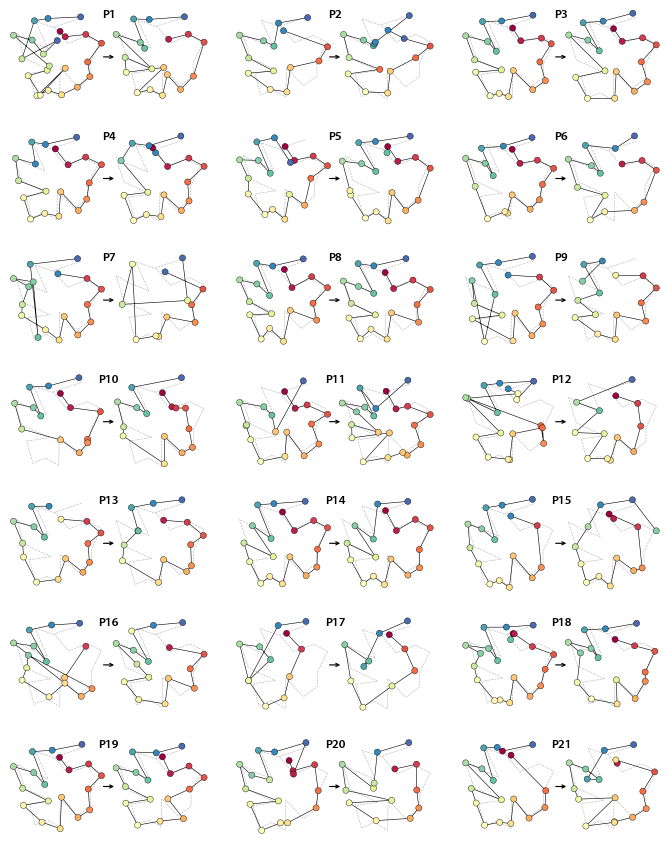

2d-trajectories-all-B.pdf


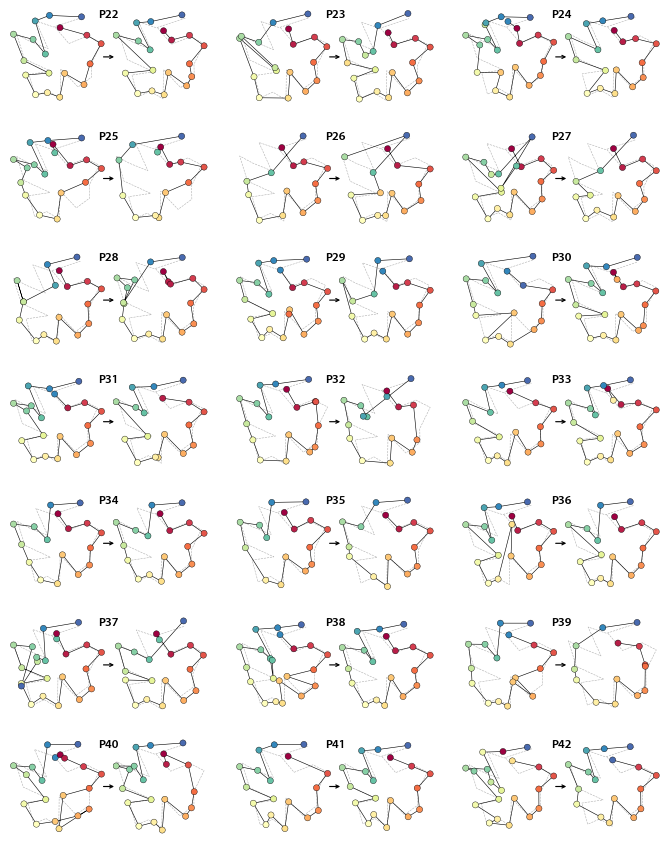

2d-trajectories-all-C.pdf


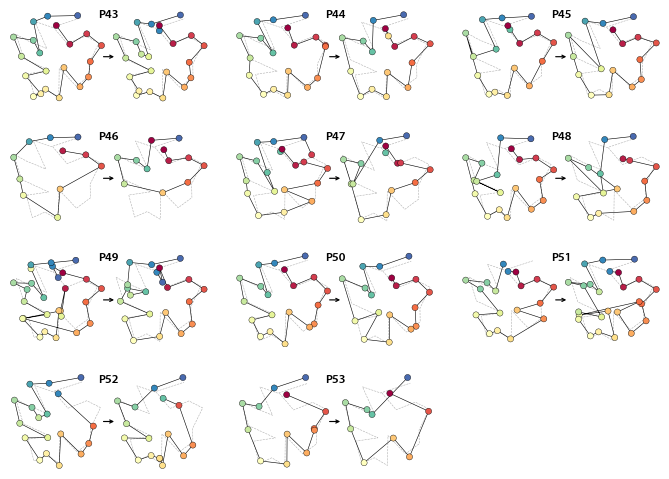

In [7]:
################################ CONFIG ################################

# plot styling
EVENT_MARKERSIZE = 250
EVENT_BORDER_LINEWIDTH = 1
EVENT_BORDER_COLOR = 'k'
CONNECTION_LINEWIDTH = 1.5
CONNECTION_LINE_COLOR = 'k'
EPISODE_UNDERLAY_COLOR = 'k'
EPISODE_UNDERLAY_ALPHA = 0.3
EPISODE_UNDERLAY_LINEWIDTH = CONNECTION_LINEWIDTH
EPISODE_UNDERLAY_LINESTYLE = '--'
DATA_BOUNDS_MARGIN = 0.08
TITLE_FONTSIZE = 9
TITLE_FONTWEIGHT = 'semibold'

# multi-page layout
PAIRS_PER_ROW = 3
ROWS_PER_PAGE = 7
PANEL_SIZE_INCHES = 0.95
WITHIN_PAIR_GAP = 0.08
BETWEEN_PAIR_GAP = 0.30
ROW_GAP = 0.28

# immediate -> delayed arrows
GRID_SCALE = PANEL_SIZE_INCHES / 3.4
PAIR_ARROW_COLOR = 'k'
PAIR_ARROW_LINEWIDTH = 3 * GRID_SCALE
PAIR_ARROW_HEAD_SCALE = 20 * GRID_SCALE
PAIR_ARROW_LENGTH_FRAC = 0.17


########################################################################


# =========================== derived values ===========================

# location of each column's left edge, in panel units
col_xs = []
for pair_ix in range(PAIRS_PER_ROW):
    imm_plot_left = pair_ix * (2 + WITHIN_PAIR_GAP + BETWEEN_PAIR_GAP)
    col_xs.append(imm_plot_left)
    col_xs.append(imm_plot_left + 1 + WITHIN_PAIR_GAP)
    
# location of each row's top edge, in panel units
row_ys = []
for row_ix in range(ROWS_PER_PAGE):
    row_ys.append(row_ix + (row_ix + 1) * ROW_GAP)

    
# total width/height of each page's fig, in panel units
fig_width = (PAIRS_PER_ROW * (2 + WITHIN_PAIR_GAP) + 
             (PAIRS_PER_ROW - 1) * BETWEEN_PAIR_GAP)
fig_height = ROWS_PER_PAGE * (1 + ROW_GAP)

participants_per_page = PAIRS_PER_ROW * ROWS_PER_PAGE
n_pages = math.ceil(len(participants) / participants_per_page)

page_file_suffixes = string.ascii_uppercase[:n_pages]


# ========================== construct figure ==========================

for page_ix in range(n_pages):
    fig = plt.figure(figsize=(fig_width * PANEL_SIZE_INCHES, 
                              fig_height * PANEL_SIZE_INCHES))
    
    # participants to show in the current page's fig
    page_participants = participants[
        page_ix * participants_per_page : (page_ix + 1) * participants_per_page
    ]
    
    axes_pairs = []
    for p_ix, p in enumerate(page_participants):
        row, pair_col = divmod(p_ix, PAIRS_PER_ROW)
        y_top = row_ys[row]
        
        # ====================== immediate recall ======================
        
        imm_axes_rect = panel_units_to_rect(x=col_xs[2 * pair_col], 
                                            y_top=y_top, 
                                            w=1, 
                                            h=1, 
                                            fig_width=fig_width, 
                                            fig_height=fig_height)
        imm_ax = fig.add_axes(imm_axes_rect)
        
        imm_event_colors = TRAJECTORY_CMAP(
            p.event_matches['atlep1'] / len(atlep1.events)
        )
        draw_episode_underlay(imm_ax)
        draw_events_path(imm_ax, p.paths_2d['atlep1'], colors=imm_event_colors)
        set_axes_limits(imm_ax, np.vstack([p.paths_2d['atlep1'], atlep1.path_2d]))
        
        
        # ======================= delayed recall =======================
        
        del_axes_rect = panel_units_to_rect(x=col_xs[2 * pair_col + 1], 
                                            y_top=y_top, 
                                            w=1, 
                                            h=1, 
                                            fig_width=fig_width, 
                                            fig_height=fig_height)
        del_ax = fig.add_axes(del_axes_rect)
        
        del_event_colors = TRAJECTORY_CMAP(
            p.event_matches['delayed'] / len(atlep1.events)
        )
        draw_episode_underlay(del_ax)
        draw_events_path(del_ax, p.paths_2d['delayed'], colors=del_event_colors)
        set_axes_limits(del_ax, np.vstack([p.paths_2d['delayed'], atlep1.path_2d]))
        
        axes_pairs.append((p, imm_ax, del_ax))
        
        
    # =================== axes pair titles & arrows ====================
        
    fig.canvas.draw()
    
    for p, imm_ax, del_ax in axes_pairs:
        box_imm, box_del = imm_ax.get_position(), del_ax.get_position()
        x_center = (box_imm.x0 + box_del.x1) / 2
        y_top = max(box_imm.y1, box_del.y1)
        fig.text(x_center, 
                 y_top, 
                 f'P{p.sub_n}', 
                 ha='center', 
                 va='top',
                 fontsize=TITLE_FONTSIZE, 
                 fontweight=TITLE_FONTWEIGHT)
        
        y_middle = (box_imm.y0 + box_imm.y1) / 2
        gap_center = (box_imm.x1 + box_del.x0) / 2
        half_len = box_imm.width * PAIR_ARROW_LENGTH_FRAC / 2
        arrow = FancyArrowPatch((gap_center - half_len, y_middle), 
                                (gap_center + half_len, y_middle),
                                arrowstyle='->',
                                color=PAIR_ARROW_COLOR, 
                                mutation_scale=PAIR_ARROW_HEAD_SCALE, 
                                linewidth=PAIR_ARROW_LINEWIDTH,
                                transform=fig.transFigure, 
                                clip_on=False)
        fig.add_artist(arrow)
                
    filename = f'2d-trajectories-all-{page_file_suffixes[page_ix]}.pdf'
#     plt.savefig(FIG_DIR / filename, bbox_inches='tight')
    print(filename)
    plt.show()